In [2]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib
import seaborn as sns
import imblearn
import wordcloud
import nltk
import xgboost

print("✅ All libraries loaded successfully!")
print(f"Pandas: {pd.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")
print(f"XGBoost: {xgboost.__version__}")

✅ All libraries loaded successfully!
Pandas: 3.0.0
Scikit-learn: 1.8.0
XGBoost: 3.2.0


In [5]:
import pandas as pd

df = pd.read_csv("online_retail_II.csv", encoding='latin-1')
print(df.shape)
print(df.head())
print(df.dtypes)

(1067371, 8)
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4  2009-12-01 07:45:00   1.25      13085.0  United Kingdom  
Invoice            str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
Price          float64
Customer ID    float64
Country            str
dtype: object


In [6]:
# Drop rows with missing Customer ID (can't track churn without it)
df.dropna(subset=['Customer ID'], inplace=True)

# Remove cancelled invoices (they start with 'C')
df = df[~df['Invoice'].astype(str).str.startswith('C')]

# Remove negative or zero quantities/prices
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create TotalAmount column
df['TotalAmount'] = df['Quantity'] * df['Price']

print("✅ Data cleaned!")
print(df.shape)

✅ Data cleaned!
(805549, 9)


In [7]:
import datetime as dt

# Reference date = day after last invoice
reference_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

rfm = df.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('Invoice', 'nunique'),
    Monetary  = ('TotalAmount', 'sum')
).reset_index()

print(rfm.head())

   Customer ID  Recency  Frequency  Monetary
0      12346.0      326         12  77556.46
1      12347.0        2          8   5633.32
2      12348.0       75          5   2019.40
3      12349.0       19          4   4428.69
4      12350.0      310          1    334.40


In [8]:
# Customers who haven't purchased in 90+ days = churned
rfm['Churn'] = (rfm['Recency'] >= 90).astype(int)

print(rfm['Churn'].value_counts())
print(f"Churn Rate: {rfm['Churn'].mean()*100:.2f}%")

Churn
1    2998
0    2880
Name: count, dtype: int64
Churn Rate: 51.00%


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score

X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree"      : DecisionTreeClassifier(),
    "Random Forest"      : RandomForestClassifier(),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\n📌 {name}")
    print(classification_report(y_test, y_pred))


📌 Logistic Regression
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       588
           1       1.00      1.00      1.00       588

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176


📌 Decision Tree
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       588
           1       1.00      1.00      1.00       588

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176


📌 Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       588
           1       1.00      1.00      1.00       588

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg     

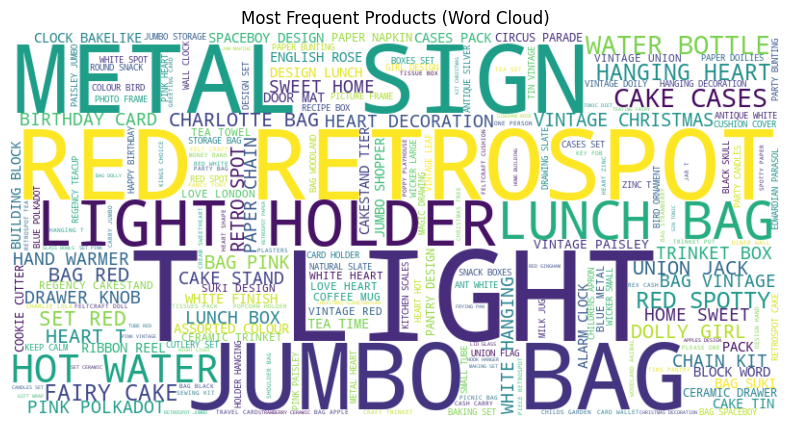

✅ TF-IDF Shape: (805549, 100)


In [10]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

# Word Cloud
text = " ".join(df['Description'].dropna().values)
wc = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(12, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Most Frequent Products (Word Cloud)")
plt.show()

# TF-IDF on product descriptions
tfidf = TfidfVectorizer(max_features=100, stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['Description'].dropna())
print("✅ TF-IDF Shape:", tfidf_matrix.shape)

C:\Users\sriva\AppData\Local\Temp\ipykernel_5868\3252813467.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=rfm, palette='Set2')


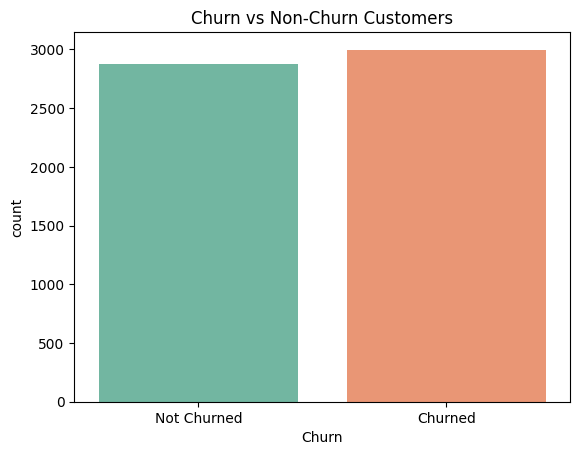

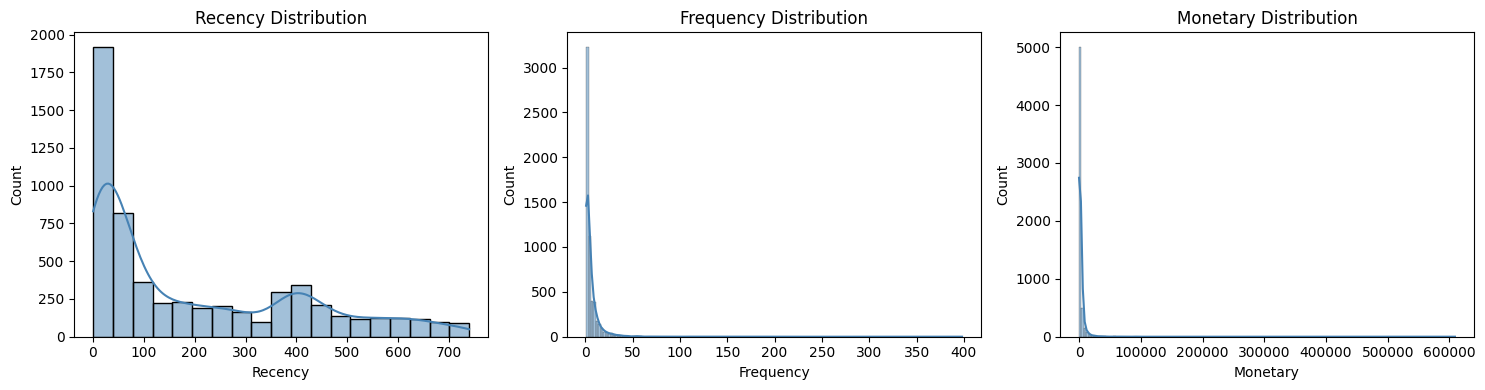

In [11]:
import seaborn as sns

# Churn distribution
sns.countplot(x='Churn', data=rfm, palette='Set2')
plt.title("Churn vs Non-Churn Customers")
plt.xticks([0,1], ['Not Churned', 'Churned'])
plt.show()

# RFM distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Recency', 'Frequency', 'Monetary']):
    sns.histplot(rfm[col], ax=ax, kde=True, color='steelblue')
    ax.set_title(f'{col} Distribution')
plt.tight_layout()
plt.show()

In [12]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE :", pd.Series(y_resampled).value_counts().to_dict())

Before SMOTE: {1: 2410, 0: 2292}
After SMOTE : {1: 2410, 0: 2410}


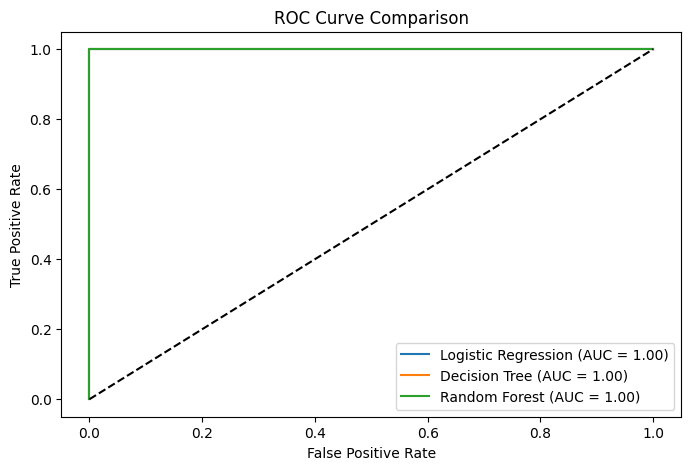

In [13]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 5))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

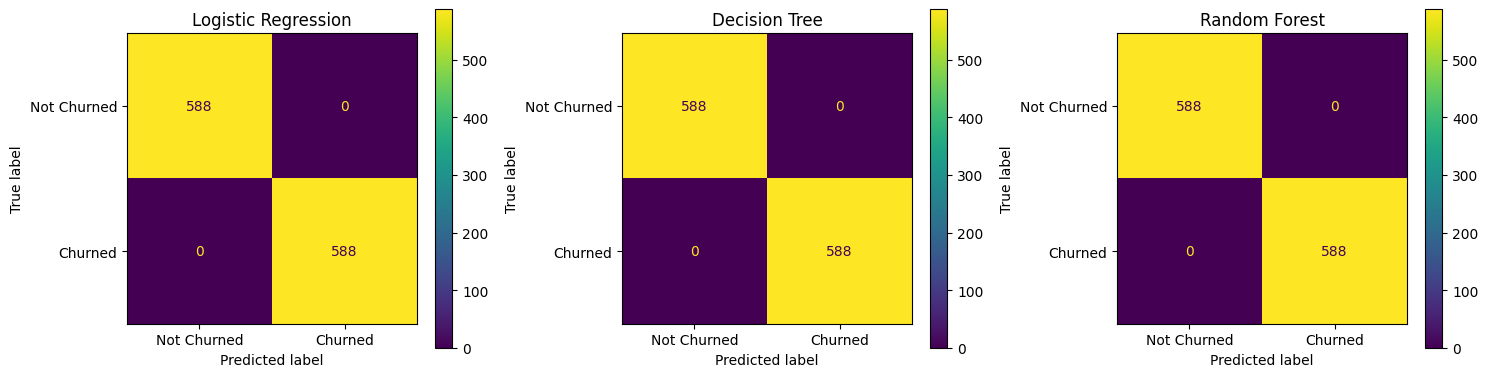

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Not Churned','Churned']).plot(ax=ax)
    ax.set_title(name)

plt.tight_layout()
plt.show()

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    results.append({
        "Model"    : name,
        "Accuracy" : accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall"   : recall_score(y_test, y_pred),
        "F1-Score" : f1_score(y_test, y_pred),
        "ROC-AUC"  : roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    })

results_df = pd.DataFrame(results)
print(results_df.round(4))

                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0  Logistic Regression       1.0        1.0     1.0       1.0      1.0
1        Decision Tree       1.0        1.0     1.0       1.0      1.0
2        Random Forest       1.0        1.0     1.0       1.0      1.0


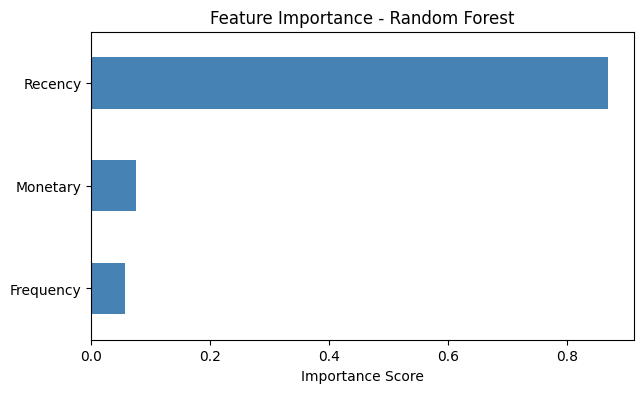

In [16]:
rf_model = models["Random Forest"]
importances = pd.Series(rf_model.feature_importances_,
                        index=['Recency','Frequency','Monetary'])

importances.sort_values().plot(kind='barh', color='steelblue', figsize=(7,4))
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.show()